# 08 · Fusion and Masks: See the Modalities Meet

**Hardware**: 🟢 CPU, zero downloads. Everything here uses a randomly-initialised miniature model — the *shape* of the mask is what matters, not the weights.

## What you will do

1. Turn `mm_token_type_ids` into block IDs and see how two images stay separated
2. Plot both attention masks and read the architecture straight off the picture
3. Confirm the finding from [index.md](../index.md) §5: **bidirectional vision attention exists only on sliding layers**
4. Reproduce the E2B mask (fully causal) and the 31B mask (blockwise) from the same code
5. Watch the sliding window clip a large image block
6. Run a real end-to-end fusion — image → processor → tower → `masked_scatter` — and trigger the count-mismatch error on purpose

In [1]:
%pip install -q "transformers>=5.14" torch pillow matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image

from transformers import (
    Gemma4Config, Gemma4TextConfig, Gemma4VisionConfig, Gemma4ForConditionalGeneration,
)
from transformers.models.gemma4.modeling_gemma4 import (
    create_masks_for_vision_model, get_block_sequence_ids_for_mask,
)
from transformers.models.gemma4.image_processing_gemma4 import Gemma4ImageProcessor

torch.manual_seed(0)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Block IDs

`mm_token_type_ids` labels each position by modality — the processor produces it, which is why `Gemma4Processor.model_input_names` appends it. `get_block_sequence_ids_for_mask` turns those labels into one integer per *contiguous vision run*, and `-1` for text.

Our layout: 4 text tokens, an 8-token image, 3 text, a second 8-token image, 5 text.

In [3]:
TEXT, IMAGE, VIDEO, AUDIO = 0, 1, 2, 3

layout = [TEXT] * 4 + [IMAGE] * 8 + [TEXT] * 3 + [IMAGE] * 8 + [TEXT] * 5
mm_token_type_ids = torch.tensor([layout])
seq_len = mm_token_type_ids.shape[1]

block_ids = get_block_sequence_ids_for_mask(mm_token_type_ids, torch.device("cpu"))

print("position :", " ".join(f"{i:>2}" for i in range(seq_len)))
print("modality :", " ".join(f"{v:>2}" for v in layout))
print("block id :", " ".join(f"{v:>2}" for v in block_ids[0].tolist()))
print("\nTwo images -> block 0 and block 1. Text is -1 and belongs to no block.")
print("Without this, image 1 could attend bidirectionally into image 2.")

position :  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27
modality :  0  0  0  0  1  1  1  1  1  1  1  1  0  0  0  1  1  1  1  1  1  1  1  0  0  0  0  0
block id : -1 -1 -1 -1  0  0  0  0  0  0  0  0 -1 -1 -1  1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1

Two images -> block 0 and block 1. Text is -1 and belongs to no block.
Without this, image 1 could attend bidirectionally into image 2.


Note `is_vision = (mm_token_type_ids == 1) | (mm_token_type_ids == 2)` — images *and* video count as vision. Audio does not: audio tokens never get bidirectional treatment.

## 2. Build both masks

In [4]:
def build_masks(seq_len, block_ids, sliding_window, bidirectional):
    cfg = Gemma4TextConfig(
        vocab_size=64, hidden_size=32, intermediate_size=64,
        num_hidden_layers=12, num_attention_heads=4, num_key_value_heads=1,
        head_dim=8, global_head_dim=16,
        sliding_window=sliding_window,
        hidden_size_per_layer_input=0,
        use_bidirectional_attention=bidirectional,
    )
    cfg._attn_implementation = "eager"
    kw = dict(
        config=cfg,
        inputs_embeds=torch.zeros(1, seq_len, cfg.hidden_size),
        attention_mask=torch.ones(1, seq_len, dtype=torch.long),
        past_key_values=None,
        position_ids=torch.arange(seq_len)[None],
    )
    return create_masks_for_vision_model(block_sequence_ids=block_ids, **kw)


def to_bool(mask):
    # Masks come back as additive float tensors; -inf means "blocked".
    m = mask[0, 0]
    return m if m.dtype == torch.bool else (m > -1e30)


masks = build_masks(seq_len, block_ids, sliding_window=8, bidirectional="vision")
for name, m in masks.items():
    print(f"{name:18s} {tuple(m.shape)}  {m.dtype}")

full_attention     (1, 1, 28, 28)  torch.float32
sliding_attention  (1, 1, 28, 28)  torch.float32


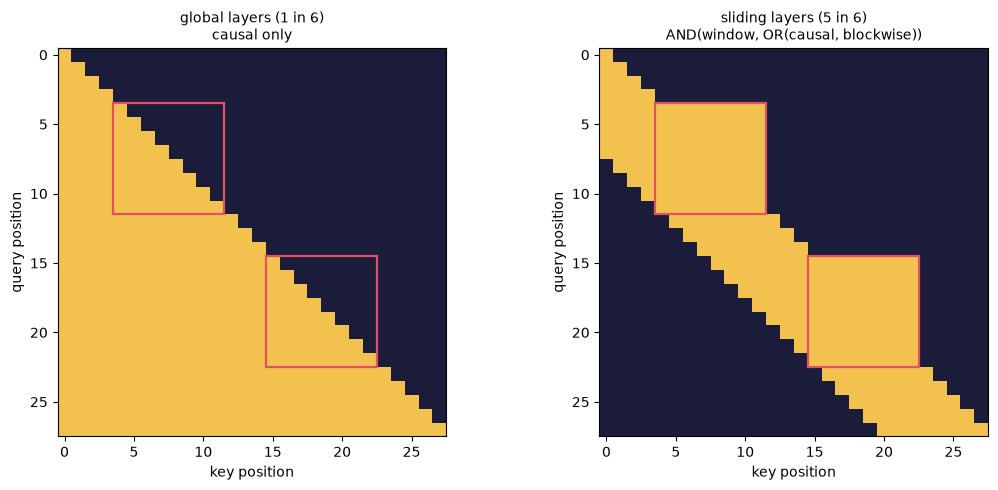

yellow = may attend, red boxes = the two image blocks


In [5]:
def show(ax, m, title):
    ax.imshow(to_bool(m).numpy(), cmap=ListedColormap(["#1b1b3a", "#f2c14e"]),
              interpolation="nearest")
    for start, end in [(4, 12), (15, 23)]:                 # the two image blocks
        ax.add_patch(plt.Rectangle((start - .5, start - .5), end - start, end - start,
                                   fill=False, ec="#e05263", lw=1.6))
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("key position"); ax.set_ylabel("query position")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
show(axes[0], masks["full_attention"],    "global layers (1 in 6)\ncausal only")
show(axes[1], masks["sliding_attention"], "sliding layers (5 in 6)\nAND(window, OR(causal, blockwise))")
plt.tight_layout(); plt.show()

print("yellow = may attend, red boxes = the two image blocks")

**That is the whole finding in one picture.** The left panel is a plain lower triangle — image tokens included. The right panel has two solid squares above the diagonal, exactly where the image blocks are.

`create_masks_for_vision_model`'s docstring states it outright:

> For global (full attention) layers: causal only (no bidirectional)
> For local (sliding window) layers: AND(sliding_window, OR(causal, blockwise))
>
> Unlike Gemma 3 (which applies bidirectional attention on all layers), Gemma 4 explicitly disables bidirectional attention on global attention layers.

The reason is caching. A global layer's KV cache is the expensive one and `generate` reuses it across decoding steps; that is only valid if entry *n* never depends on anything after *n*. Sliding layers can afford bidirectionality because their window is small and image spans are fully present at prefill.

## 3. Read it as ASCII

Sometimes the grid is clearer than the heatmap.

In [6]:
def ascii_mask(m, rows=None):
    b = to_bool(m)
    rows = rows or range(b.shape[0])
    for i in rows:
        tag = {1: "IMG", 0: "txt"}[layout[i]]
        print(f"  q={i:>2} {tag} " + "".join("#" if x else "." for x in b[i].tolist()))

print("sliding layers:")
ascii_mask(masks["sliding_attention"], rows=range(0, 16))

sliding layers:
  q= 0 txt #...........................
  q= 1 txt ##..........................
  q= 2 txt ###.........................
  q= 3 txt ####........................
  q= 4 IMG ############................
  q= 5 IMG ############................
  q= 6 IMG ############................
  q= 7 IMG ############................
  q= 8 IMG .###########................
  q= 9 IMG ..##########................
  q=10 IMG ...#########................
  q=11 IMG ....########................
  q=12 txt .....########...............
  q=13 txt ......########..............
  q=14 txt .......########.............
  q=15 IMG ........###############.....


Rows 4–11 are the first image block, and each of them reaches all the way to column 11 — every image token sees the whole image, forwards and backwards. Then look at rows 8 onward: the left edge starts creeping right. That is `sliding_window=8` clipping the block from behind.

## 4. The window clips large blocks

`AND(sliding_window, OR(causal, blockwise))` — the window is applied *after* the block union, so a block wider than the window is **not** fully bidirectional.

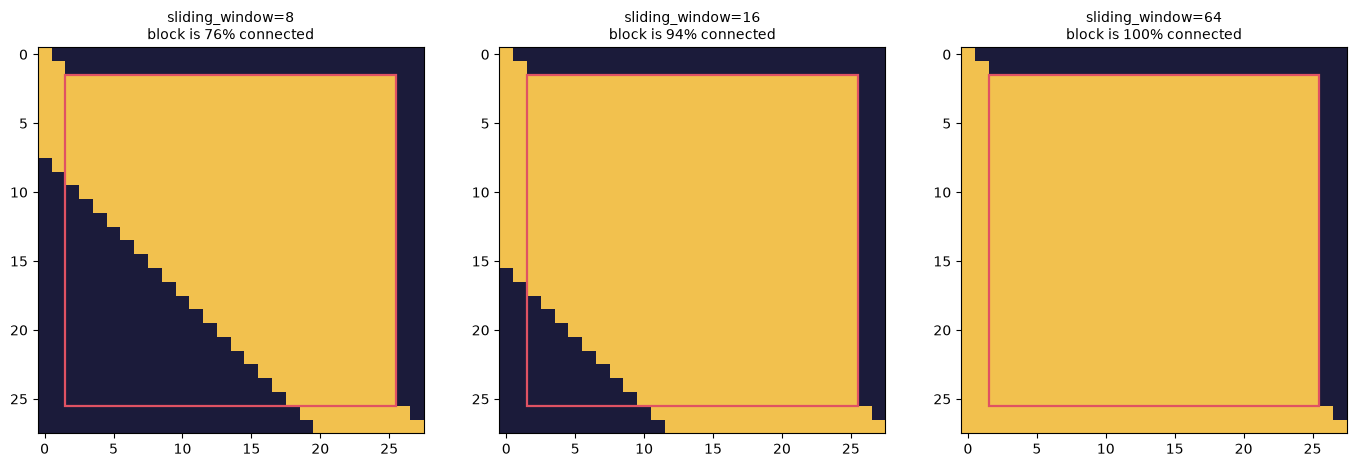

A 24-token block under a window of 8 is nowhere near fully bidirectional.
Real numbers: an image is 280 soft tokens; E2B's window is 512, the large sizes' is 1024.
One image fits. Two adjacent 1120-token images do not.


In [7]:
big_layout = [TEXT] * 2 + [IMAGE] * 24 + [TEXT] * 2
big_mm = torch.tensor([big_layout])
big_blocks = get_block_sequence_ids_for_mask(big_mm, torch.device("cpu"))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, w in zip(axes, [8, 16, 64]):
    m = build_masks(len(big_layout), big_blocks, sliding_window=w, bidirectional="vision")
    ax.imshow(to_bool(m["sliding_attention"]).numpy(),
              cmap=ListedColormap(["#1b1b3a", "#f2c14e"]), interpolation="nearest")
    ax.add_patch(plt.Rectangle((1.5, 1.5), 24, 24, fill=False, ec="#e05263", lw=1.6))
    frac = to_bool(m["sliding_attention"])[2:26, 2:26].float().mean()
    ax.set_title(f"sliding_window={w}\nblock is {100*frac:.0f}% connected", fontsize=10)
plt.tight_layout(); plt.show()

print("A 24-token block under a window of 8 is nowhere near fully bidirectional.")
print("Real numbers: an image is 280 soft tokens; E2B's window is 512, the large sizes' is 1024.")
print("One image fits. Two adjacent 1120-token images do not.")

## 5. Same code, two checkpoints, two masks

E2B and E4B leave `use_bidirectional_attention` unset. `Gemma4Model.forward` then takes a different branch entirely:

```python
use_bidir = text_config.use_bidirectional_attention == "vision"
if use_bidir and mm_token_type_ids is not None:
    causal_mask_mapping = create_masks_for_vision_model(...)
else:
    causal_mask_mapping = create_masks_for_generate(**mask_kwargs)
```

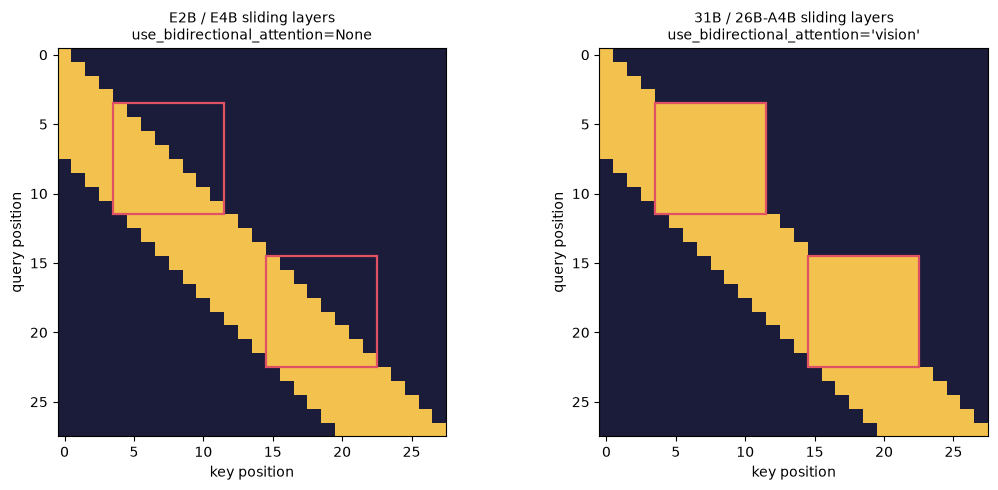

Left: image tokens are as causal as text. The top-left patch never sees the bottom-right one.
Right: the blocks are solid.

Same library, same prompt — the checkpoint's config decides.


In [8]:
from transformers.masking_utils import create_masks_for_generate

cfg_e2b = Gemma4TextConfig(
    vocab_size=64, hidden_size=32, intermediate_size=64, num_hidden_layers=12,
    num_attention_heads=4, num_key_value_heads=1, head_dim=8, global_head_dim=16,
    sliding_window=8, hidden_size_per_layer_input=0, use_bidirectional_attention=None)
cfg_e2b._attn_implementation = "eager"

e2b_masks = create_masks_for_generate(
    config=cfg_e2b, inputs_embeds=torch.zeros(1, seq_len, 32),
    attention_mask=torch.ones(1, seq_len, dtype=torch.long),
    past_key_values=None, position_ids=torch.arange(seq_len)[None])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
show(axes[0], e2b_masks["sliding_attention"],  "E2B / E4B sliding layers\nuse_bidirectional_attention=None")
show(axes[1], masks["sliding_attention"],      "31B / 26B-A4B sliding layers\nuse_bidirectional_attention='vision'")
plt.tight_layout(); plt.show()

print("Left: image tokens are as causal as text. The top-left patch never sees the bottom-right one.")
print("Right: the blocks are solid.")
print("\nSame library, same prompt — the checkpoint's config decides.")

## 6. Fusion, end to end

Now the other half of the chapter: actually putting soft tokens into the sequence. A miniature multimodal model, a real image, the real image processor.

In [9]:
SOFT = 70   # smallest menu entry, so the mini tower stays fast

text_config = Gemma4TextConfig(
    vocab_size=2048, hidden_size=32, intermediate_size=64, num_hidden_layers=12,
    num_attention_heads=4, num_key_value_heads=1, head_dim=8, global_head_dim=16,
    sliding_window=64, hidden_size_per_layer_input=0, use_bidirectional_attention="vision")
vision_config = Gemma4VisionConfig(
    hidden_size=64, intermediate_size=128, num_hidden_layers=2, num_attention_heads=4,
    num_key_value_heads=4, head_dim=16, patch_size=16, pooling_kernel_size=3,
    position_embedding_size=1024)
config = Gemma4Config(text_config=text_config, vision_config=vision_config, audio_config=None,
                      image_token_id=1000, audio_token_id=1001, video_token_id=1002,
                      boi_token_id=1003, eoi_token_id=1004)

model = Gemma4ForConditionalGeneration(config).eval()

image = Image.fromarray(np.random.randint(0, 256, (240, 320, 3), dtype=np.uint8))
enc = Gemma4ImageProcessor(max_soft_tokens=SOFT)([image], return_tensors="pt")
n_soft = int(enc["num_soft_tokens_per_image"][0])
print(f"pixel_values {tuple(enc['pixel_values'].shape)}  ->  {n_soft} real soft tokens")

pixel_values (1, 630, 768)  ->  63 real soft tokens


In [10]:
# Build input_ids the way the processor would: <boi> + n_soft placeholders + <eoi>
input_ids = torch.cat([
    torch.randint(0, 900, (1, 4)),
    torch.full((1, 1), config.boi_token_id),
    torch.full((1, n_soft), config.image_token_id),
    torch.full((1, 1), config.eoi_token_id),
    torch.randint(0, 900, (1, 5)),
], dim=1)
print("input_ids length:", input_ids.shape[1])

image_mask, video_mask, audio_mask = model.model.get_placeholder_mask(input_ids, None)
print("placeholders found by get_placeholder_mask:", int(image_mask.sum()))

features = model.model.get_image_features(
    enc["pixel_values"], enc["image_position_ids"], return_dict=True).pooler_output
print("soft tokens produced by the tower :", tuple(features.shape))
print("\nThe two numbers must match. Everything in chapters 03-05 exists to make the")
print("right-hand number predictable; everything in chapter 02 makes the left-hand one.")

input_ids length: 74
placeholders found by get_placeholder_mask: 63
soft tokens produced by the tower : (63, 32)

The two numbers must match. Everything in chapters 03-05 exists to make the
right-hand number predictable; everything in chapter 02 makes the left-hand one.


In [11]:
with torch.no_grad():
    out = model(input_ids=input_ids,
                pixel_values=enc["pixel_values"],
                image_position_ids=enc["image_position_ids"])
print("logits:", tuple(out.logits.shape))
print("image_hidden_states:", tuple(out.image_hidden_states.shape))

logits: (1, 74, 2048)
image_hidden_states: (63, 32)


### Break it on purpose

The guard is `torch_compilable_check` rather than a plain `assert` so it survives `torch.compile`. Give the model one placeholder too few and read the message — you will meet it for real the first time you hand-build inputs, or the first time a processor version and a model version disagree.

In [12]:
bad_ids = torch.cat([
    torch.randint(0, 900, (1, 4)),
    torch.full((1, n_soft - 1), config.image_token_id),   # one short
    torch.randint(0, 900, (1, 5)),
], dim=1)

try:
    with torch.no_grad():
        model(input_ids=bad_ids, pixel_values=enc["pixel_values"],
              image_position_ids=enc["image_position_ids"])
except Exception as e:
    print(type(e).__name__, "->", str(e)[:200])

ValueError -> Image features and image tokens do not match, tokens: 62, features: 63


### Watch the scatter happen

`masked_scatter` is the fusion. Before it, placeholder positions hold the *pad* embedding (they were rewritten to `pad_token_id` to keep the embedding lookup in range). After it, they hold soft tokens.

positions changed by masked_scatter: 63 of 74
changed indices: [5, 6, 7, 8, 9, 10, 11, 12] ...


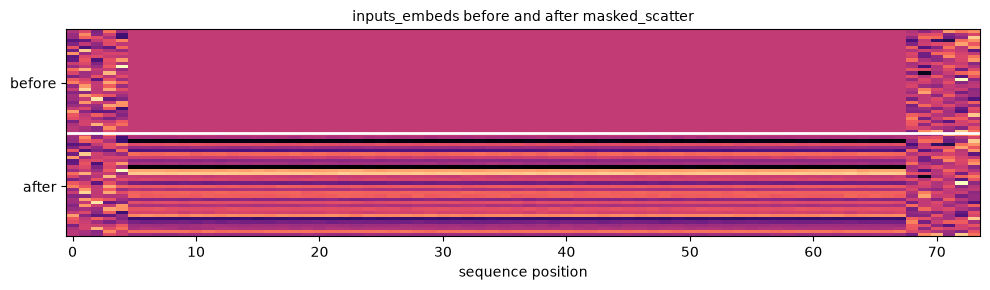


The flat band in 'before' is the repeated pad embedding. In 'after' it is image content.
From this point on, nothing downstream knows an image was ever involved.


In [13]:
multimodal_mask = image_mask | video_mask | audio_mask
llm_input_ids = torch.where(multimodal_mask, config.text_config.pad_token_id, input_ids)
before = model.model.get_input_embeddings()(llm_input_ids)

expanded = image_mask.unsqueeze(-1).expand_as(before)
after = before.masked_scatter(expanded, features.to(before.dtype))

changed = (before != after).any(-1)[0]
print("positions changed by masked_scatter:", changed.sum().item(), "of", changed.numel())
print("changed indices:", changed.nonzero().flatten().tolist()[:8], "...")

fig, ax = plt.subplots(figsize=(10, 3))
ax.imshow(torch.cat([before[0].T, after[0].T]).detach().numpy(), aspect="auto", cmap="magma")
ax.axhline(before.shape[-1] - 0.5, color="w", lw=2)
ax.set_yticks([before.shape[-1] // 2, before.shape[-1] * 3 // 2])
ax.set_yticklabels(["before", "after"])
ax.set_xlabel("sequence position")
ax.set_title("inputs_embeds before and after masked_scatter", fontsize=10)
plt.tight_layout(); plt.show()

print("\nThe flat band in 'before' is the repeated pad embedding. In 'after' it is image content.")
print("From this point on, nothing downstream knows an image was ever involved.")

## Exercises

1. Change the layout so the two images are *adjacent* with no text between them. How many blocks does `get_block_sequence_ids_for_mask` produce, and is that the behaviour you want?
2. Set `use_bidirectional_attention="all"`. Predict what happens to `sliding_window` before you run it — `Gemma4TextConfig.__post_init__` has a surprise (chapter 01 §3).
3. Put an audio run in the layout (`AUDIO = 3`). Does it get a block? Find the line in `get_block_sequence_ids_for_mask` that decides.
4. With `sliding_window=8` and a 24-token block, compute the fraction of within-block pairs that are connected, and derive a formula in terms of window and block size.
5. Feed the model `inputs_embeds` instead of `input_ids` and see which branch of `get_placeholder_mask` runs. Why does it need to embed a token to do its job?
6. Add a second image to the end-to-end example. What has to change in `input_ids`, and what shape does `pixel_values` take?

## Where next

[Chapter 09](../../09-generation-and-serving/index.md) turns this single forward pass into a decoding loop — and the causal-global-layer decision you just plotted is exactly what makes the KV cache valid.